# 📸 Notebook 1 — Image Data Processing & Analysis
### Two-Stage GAN Inpainting · CelebA + FFHQ + Places365

**Contents:**
1. Imports & configuration
2. Dataset scanning & splits
3. Exploratory data analysis
4. Preprocessing transforms & edge detection
5. Mask generation
6. Dataset class & DataLoader
7. Batch verification
8. Save artefacts for Notebook 2

---
### Expected folder layout
```
project/
├── data/
│   ├── celeba/img_align_celeba/   ← CelebA images (.jpg)
│   ├── ffhq/images256x256/      ← FFHQ numbered subfolders
│   ├── places/images/             ← Places365 category subfolders
│   └── masks/irregular_masks/     ← Mask .png files
├── 01_data_processing_analysis.ipynb
└── 02_model_training.ipynb
```
> The notebook runs fine without any real data — synthetic placeholders are used automatically.

---
## 1 · Imports & Configuration

In [1]:
import os, json, random, math, warnings
from pathlib import Path
from collections import Counter
from typing import List, Optional, Dict

import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from PIL import Image

import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f'GPU     : {p.name}  ({p.total_memory/1e9:.1f} GB)')

# ── Paths ─────────────────────────────────────────────────────────
ROOT       = Path('data')
CELEBA_DIR = ROOT / 'celeba'  / 'img_align_celeba' / 'img_align_celeba'
FFHQ_DIR   = ROOT / 'ffhq'   / 'images256x256'
PLACES_DIR = ROOT / 'places' / 'images'
MASK_DIR   = ROOT / 'masks'  / 'irregular_masks'
CACHE_DIR  = ROOT / 'cache'
SPLIT_DIR  = ROOT / 'splits'

for d in [CACHE_DIR, SPLIT_DIR, MASK_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Image settings ────────────────────────────────────────────────
IMG_SIZE   = 256
BATCH_SIZE = 16
N_WORKERS  = 0
GAN_MEAN   = [0.5, 0.5, 0.5]   # normalise to [-1, 1] for GAN
GAN_STD    = [0.5, 0.5, 0.5]

# ── Mask coverage bins ────────────────────────────────────────────
MASK_BINS = [
    (0.10, 0.20, '10–20%'),
    (0.20, 0.30, '20–30%'),
    (0.30, 0.40, '30–40%'),
    (0.40, 0.50, '40–50%'),
]

# ── Pastel colour palette (used in every plot) ────────────────────
PASTEL = dict(
    blue='#A8C7E8', purple='#C8B8E8', teal='#A8D8D0',
    peach='#F5C9A0', pink='#F0B8C8',  yellow='#F5E6A0',
    green='#B8E0B8', lavender='#D4C5F0'
)
PAL  = list(PASTEL.values())
BG   = '#FAFBFC'
GRID = '#E8ECF0'
INK  = '#2C3E50'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor': BG,
    'axes.grid': True,        'grid.color': GRID,    'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False,'axes.spines.bottom': False,
    'font.size': 11,          'axes.titlesize': 13,  'axes.titleweight': 'bold',
    'axes.labelcolor': INK,   'xtick.color': INK,    'ytick.color': INK,
    'text.color': INK,        'savefig.dpi': 150,    'savefig.bbox': 'tight',
})

print('\n✅  Setup complete.')

PyTorch : 2.8.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 3060 Laptop GPU  (6.4 GB)

✅  Setup complete.


---
## 2 · Dataset Scanning & Splits

In [2]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.webp')

def scan(directory: Path) -> List[Path]:
    if not directory.exists():
        print(f'  ⚠  Not found: {directory}')
        return []
    paths = sorted(p for p in directory.rglob('*')
                   if p.suffix.lower() in IMG_EXTS)
    print(f'  {directory.parent.name:<12}: {len(paths):>8,} images')
    return paths


def make_splits(paths: List[Path], prefix: str,
                train=0.80, val=0.10) -> Dict[str, List[Path]]:
    cache = SPLIT_DIR / f'{prefix}_splits.json'
    if cache.exists():
        with open(cache) as f:
            d = json.load(f)
        print(f'  Loaded cached splits for {prefix}')
        return {k: [Path(p) for p in v] for k, v in d.items()}

    idx     = np.random.default_rng(SEED).permutation(len(paths))
    n_tr    = int(len(paths) * train)
    n_val   = int(len(paths) * val)
    splits  = {
        'train': [paths[i] for i in idx[:n_tr]],
        'val'  : [paths[i] for i in idx[n_tr:n_tr+n_val]],
        'test' : [paths[i] for i in idx[n_tr+n_val:]],
    }
    with open(cache, 'w') as f:
        json.dump({k: [str(p) for p in v] for k, v in splits.items()}, f)
    return splits


print('Scanning datasets…')
celeba_paths = scan(CELEBA_DIR)
ffhq_paths   = scan(FFHQ_DIR)
places_paths = scan(PLACES_DIR)
mask_paths   = scan(MASK_DIR)

# Choose the primary dataset (CelebA first, then FFHQ, then synthetic)
if celeba_paths:
    primary, prefix = celeba_paths, 'celeba'
elif ffhq_paths:
    primary, prefix = ffhq_paths,   'ffhq'
else:
    print('\n  ⚠  No real images found — generating synthetic placeholders…')
    syn_dir = CACHE_DIR / 'synthetic'
    syn_dir.mkdir(exist_ok=True)
    rng = np.random.default_rng(SEED)
    for i in range(300):
        p = syn_dir / f'img_{i:04d}.png'
        if not p.exists():
            Image.fromarray(rng.integers(80, 220, (256, 256, 3), dtype=np.uint8)).save(p)
    primary, prefix = sorted(syn_dir.glob('*.png')), 'synthetic'
    print(f'  Created {len(primary)} synthetic images')

splits = make_splits(primary, prefix)
print(f'\n  Split  →  train: {len(splits["train"]):,}  '
      f'val: {len(splits["val"]):,}  test: {len(splits["test"]):,}')

Scanning datasets…
  img_align_celeba:  202,599 images
  ffhq        :   70,000 images
  ⚠  Not found: data\places\images
  masks       :   32,000 images
  Loaded cached splits for celeba

  Split  →  train: 162,079  val: 20,259  test: 20,261


---
## 3 · Exploratory Data Analysis

In [3]:
def sample(paths, n):
    return random.sample(paths, min(n, len(paths)))

def load_rgb(p, size=None):
    try:
        img = Image.open(p).convert('RGB')
        if size: img = img.resize((size, size), Image.LANCZOS)
        return np.array(img)
    except Exception:
        return None


# ── Collect resolution info ───────────────────────────────────────
DATASETS = [
    ('CelebA',    celeba_paths),
    ('FFHQ',      ffhq_paths),
    ('Places365', places_paths),
]

res_data = {}
for name, paths in DATASETS:
    records = []
    if paths:
        for p in tqdm(sample(paths, 300), desc=name, leave=False):
            try:
                with Image.open(p) as img:
                    w, h = img.size
                    records.append({'w': w, 'h': h, 'ar': w/h})
            except: pass
        res_data[name] = pd.DataFrame(records)
    else:
        # Synthetic placeholder stats
        rng = np.random.default_rng(SEED)
        if name == 'CelebA':
            w = rng.integers(175, 185, 300); h = rng.integers(215, 225, 300)
        elif name == 'FFHQ':
            w = np.full(300, 1024);          h = np.full(300, 1024)
        else:
            w = rng.integers(256, 300, 300); h = rng.integers(256, 300, 300)
        res_data[name] = pd.DataFrame({'w': w, 'h': h, 'ar': w/h})
        print(f'  ⚠  {name}: using placeholder stats')

print('✅  Resolution scan done.')

CelebA:   0%|          | 0/300 [00:00<?, ?it/s]

FFHQ:   0%|          | 0/300 [00:00<?, ?it/s]

  ⚠  Places365: using placeholder stats
✅  Resolution scan done.


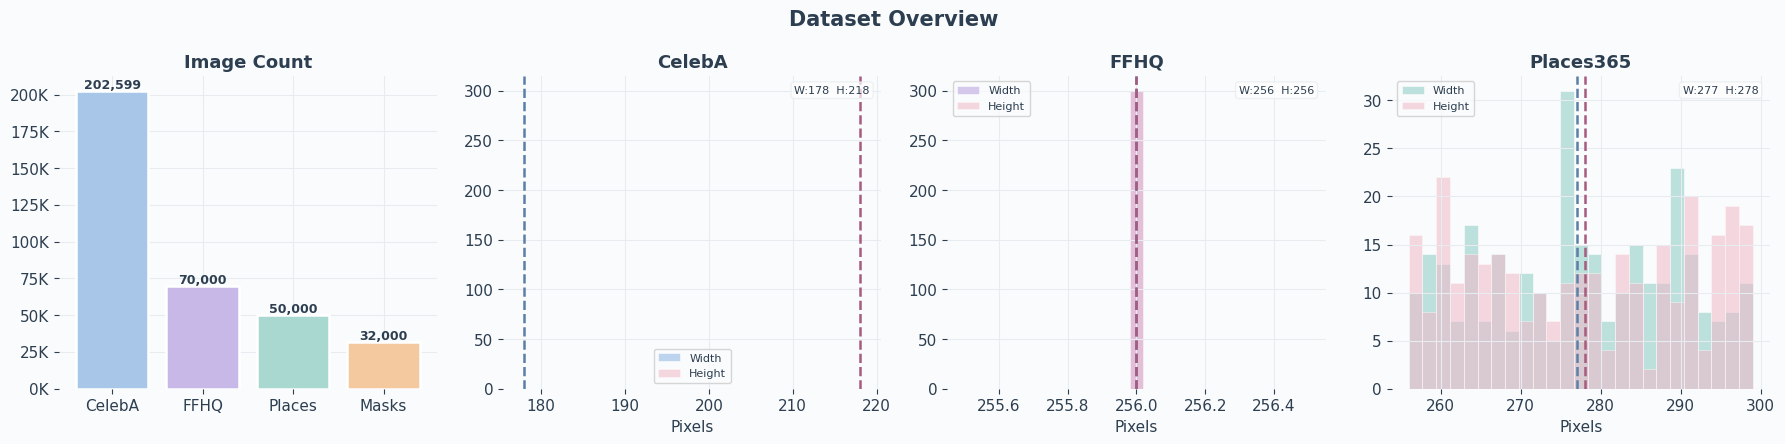

In [4]:
# ── PLOT A: Dataset sizes + resolution distributions ──────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle('Dataset Overview', fontsize=15, fontweight='bold')

# Dataset size bar
ax = axes[0]
sizes  = {'CelebA': max(len(celeba_paths), 202_599),
           'FFHQ':   max(len(ffhq_paths),   70_000),
           'Places': max(len(places_paths),  50_000),
           'Masks':  max(len(mask_paths),    12_000)}
bars = ax.bar(sizes.keys(), sizes.values(),
              color=[PASTEL['blue'], PASTEL['purple'],
                     PASTEL['teal'], PASTEL['peach']],
              edgecolor='white', linewidth=1.8, zorder=3)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1500,
            f'{b.get_height():,.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Image Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Resolution histograms for each dataset
for ax, (name, df), col in zip(
        axes[1:],
        res_data.items(),
        [PASTEL['blue'], PASTEL['purple'], PASTEL['teal']]):
    ax.hist(df['w'], bins=25, alpha=0.75, color=col,
            label='Width',  edgecolor='white', linewidth=0.5)
    ax.hist(df['h'], bins=25, alpha=0.55, color=PASTEL['pink'],
            label='Height', edgecolor='white', linewidth=0.5)
    ax.axvline(df['w'].median(), color='#5B7FA6', linestyle='--', linewidth=1.8)
    ax.axvline(df['h'].median(), color='#A65B7F', linestyle='--', linewidth=1.8)
    ax.set_title(name)
    ax.set_xlabel('Pixels')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.97,
            f"W:{df['w'].median():.0f}  H:{df['h'].median():.0f}",
            transform=ax.transAxes, va='top', ha='right', fontsize=8,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor=GRID, boxstyle='round'))

plt.tight_layout()
plt.savefig(CACHE_DIR / 'eda_01_overview.png')
plt.show()

CelebA:   0%|          | 0/250 [00:00<?, ?it/s]

FFHQ:   0%|          | 0/250 [00:00<?, ?it/s]

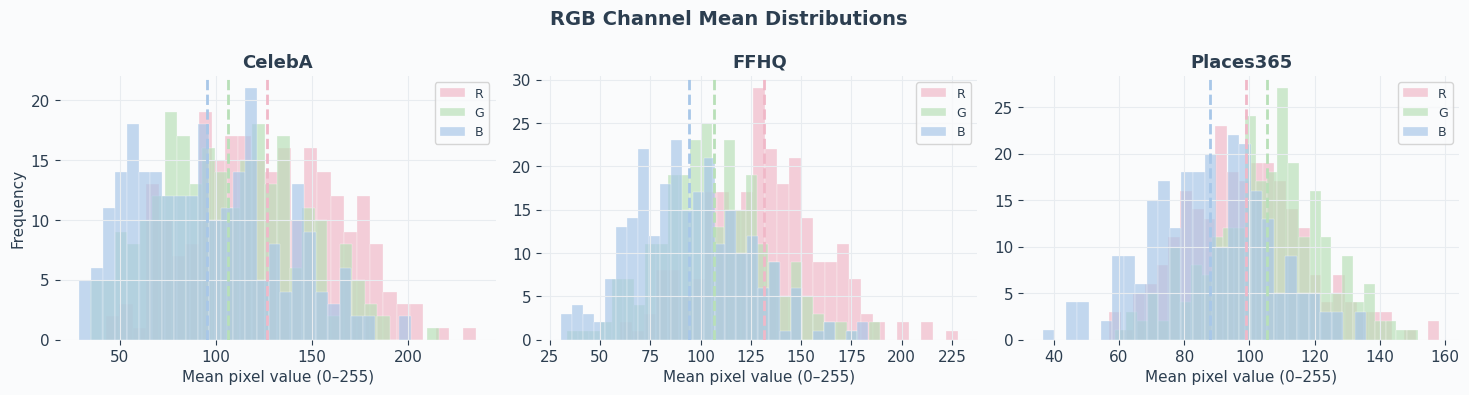

In [5]:
# ── PLOT B: RGB channel statistics ────────────────────────────────
ch_stats = {}
for name, paths in DATASETS:
    if paths:
        R, G, B = [], [], []
        for p in tqdm(sample(paths, 250), desc=name, leave=False):
            img = load_rgb(p, size=64)
            if img is None: continue
            R.append(img[:,:,0].mean())
            G.append(img[:,:,1].mean())
            B.append(img[:,:,2].mean())
        ch_stats[name] = {'R': np.array(R), 'G': np.array(G), 'B': np.array(B)}
    else:
        rng = np.random.default_rng(SEED)
        bases = {'CelebA': (160,130,115), 'FFHQ': (155,128,118), 'Places365': (100,105,90)}
        m = bases.get(name, (128,128,128))
        ch_stats[name] = {
            'R': rng.normal(m[0], 20, 250),
            'G': rng.normal(m[1], 18, 250),
            'B': rng.normal(m[2], 18, 250),
        }

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RGB Channel Mean Distributions', fontsize=14, fontweight='bold')

for ax, (name, st) in zip(axes, ch_stats.items()):
    for ch, col in [('R', PASTEL['pink']), ('G', PASTEL['green']), ('B', PASTEL['blue'])]:
        ax.hist(st[ch], bins=28, alpha=0.68, color=col,
                label=ch, edgecolor='white', linewidth=0.3)
        ax.axvline(st[ch].mean(), color=col, linestyle='--', linewidth=2)
    ax.set_title(name)
    ax.set_xlabel('Mean pixel value (0–255)')
    if ax is axes[0]: ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'eda_02_channels.png')
plt.show()

---
## 4 · Preprocessing Transforms & Edge Detection

In [6]:
def train_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size, size), interpolation=T.InterpolationMode.LANCZOS),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.02),
        T.ToTensor(),
        T.Normalize(GAN_MEAN, GAN_STD),
    ])


def val_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size, size), interpolation=T.InterpolationMode.LANCZOS),
        T.ToTensor(),
        T.Normalize(GAN_MEAN, GAN_STD),
    ])


def denorm(t: torch.Tensor) -> torch.Tensor:
    """[-1,1] tensor → [0,1]"""
    return (t * 0.5 + 0.5).clamp(0, 1)


def to_np(t: torch.Tensor) -> np.ndarray:
    """(C,H,W) float tensor → (H,W,C) uint8"""
    return (denorm(t).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)


def canny_edges(img_rgb: np.ndarray,
                low=50, high=150, blur=3) -> np.ndarray:
    """RGB uint8 → float32 edge map in [0,1]"""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    if blur > 1:
        gray = cv2.GaussianBlur(gray, (blur, blur), 0)
    return (cv2.Canny(gray, low, high) / 255.0).astype(np.float32)


print('✅  Transforms and edge detection ready.')

✅  Transforms and edge detection ready.


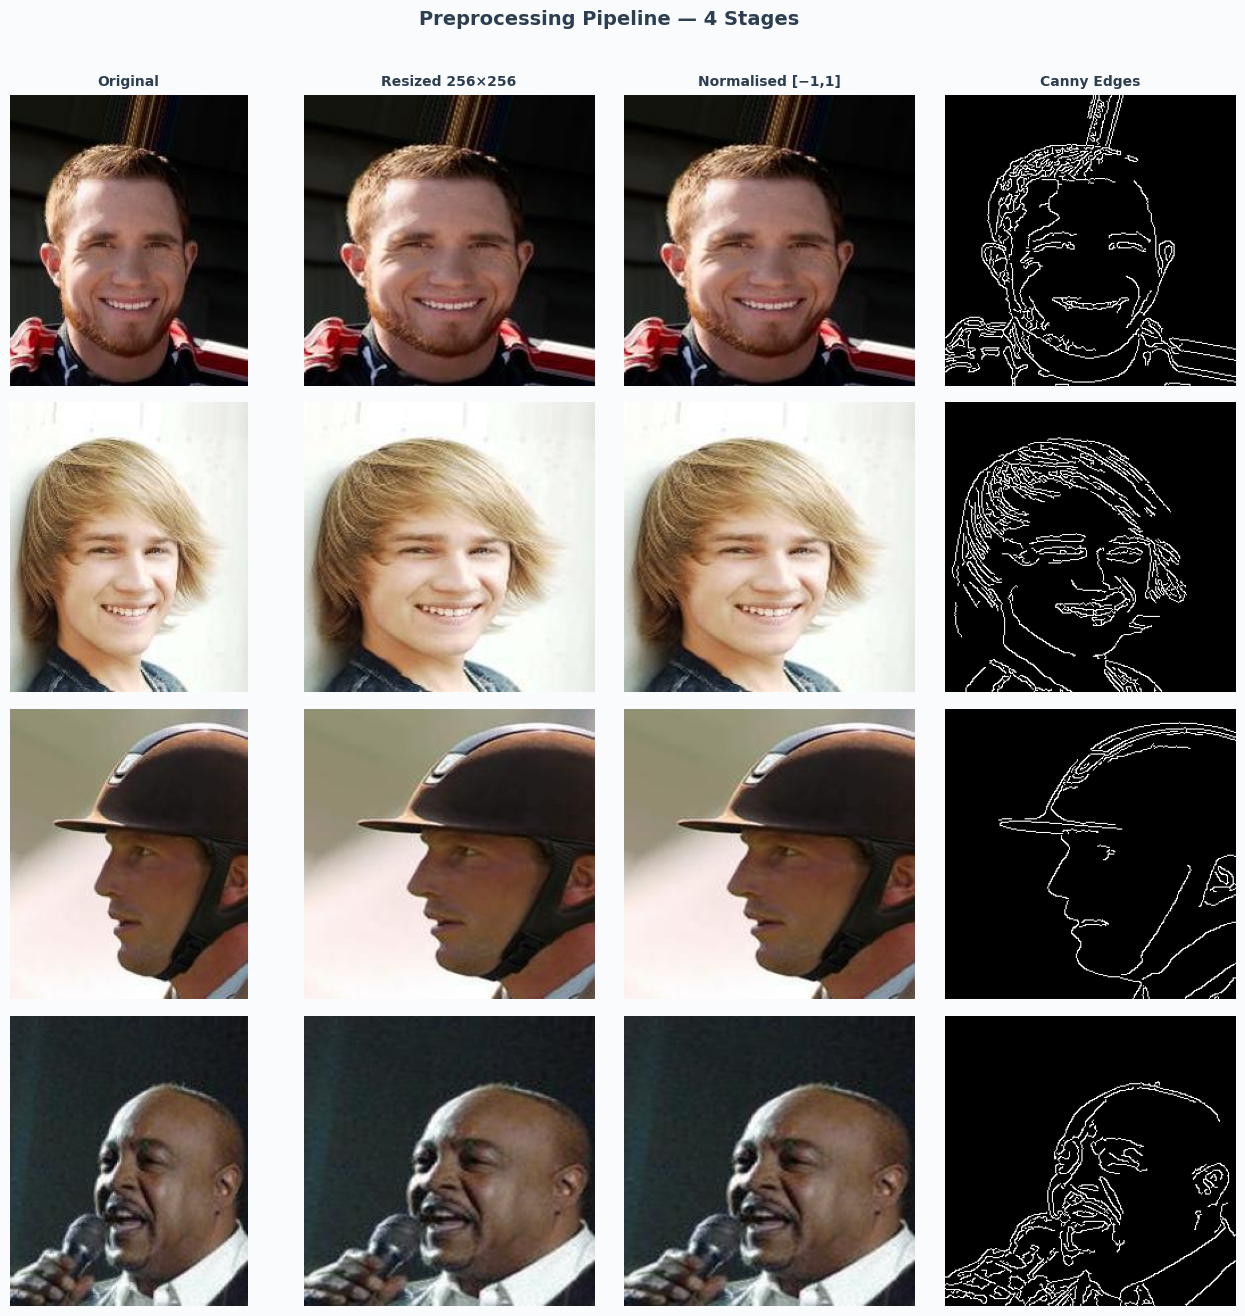

In [7]:
# ── PLOT C: Preprocessing pipeline visualisation ──────────────────
all_src = celeba_paths or ffhq_paths or places_paths
examples = []
if all_src:
    for p in sample(all_src, 4):
        arr = load_rgb(p)
        if arr is not None: examples.append(arr)

# Fill with synthetic if needed
rng = np.random.default_rng(SEED)
while len(examples) < 4:
    examples.append(rng.integers(100, 220, (218, 178, 3), dtype=np.uint8))

tf  = val_transform()
fig, axes = plt.subplots(4, 4, figsize=(13, 13))
fig.suptitle('Preprocessing Pipeline — 4 Stages',
             fontsize=14, fontweight='bold', y=1.01)

for col, title in enumerate(
        ['Original', f'Resized {IMG_SIZE}×{IMG_SIZE}',
         'Normalised [−1,1]', 'Canny Edges']):
    axes[0][col].set_title(title, fontsize=10, fontweight='bold', pad=7)

for row, orig in enumerate(examples):
    pil_rsz  = Image.fromarray(orig).convert('RGB').resize(
                   (IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    t        = tf(pil_rsz)
    resized  = np.array(pil_rsz)
    normed   = to_np(t)
    edges    = canny_edges(resized)

    for col, (img, cmap) in enumerate([
            (orig,    None),
            (resized, None),
            (normed,  None),
            (edges,   'Greys_r')]):
        ax = axes[row][col]
        ax.imshow(img, cmap=cmap)
        ax.axis('off')
        if col == 0:
            h, w = orig.shape[:2]
            ax.set_xlabel(f'{w}×{h}', fontsize=8)
        if col == 3:
            ax.set_xlabel(f'density: {edges.mean()*100:.1f}%', fontsize=8)

plt.tight_layout()
plt.savefig(CACHE_DIR / 'eda_03_preprocessing.png')
plt.show()

---
## 5 · Mask Generation

In [8]:
class MaskGenerator:
    """
    Generates irregular inpainting masks using random
    brush strokes and ellipses, targeting a coverage range.
    """
    def __init__(self, size=IMG_SIZE, max_attempts=60):
        self.size = size
        self.max_attempts = max_attempts

    def _stroke(self, mask, rng):
        brush = rng.integers(max(1, self.size//64), max(3, self.size//10))
        angle = rng.uniform(0, 2*math.pi)
        pts   = [(rng.integers(0, self.size), rng.integers(0, self.size))]
        for _ in range(rng.integers(4, 14) - 1):
            angle += rng.uniform(-math.pi/2, math.pi/2)
            step   = rng.integers(self.size//10, self.size//3)
            pts.append((
                int(np.clip(pts[-1][0] + step*math.cos(angle), 0, self.size-1)),
                int(np.clip(pts[-1][1] + step*math.sin(angle), 0, self.size-1)),
            ))
        for i in range(len(pts)-1):
            cv2.line(mask, pts[i], pts[i+1], 1, brush)
        return mask

    def _ellipse(self, mask, rng):
        cx, cy = rng.integers(self.size//4, 3*self.size//4, 2)
        ra, rb = rng.integers(self.size//20, self.size//6, 2)
        cv2.ellipse(mask, (cx, cy), (ra, rb), rng.integers(0, 180), 0, 360, 1, -1)
        return mask

    def generate(self, lo=0.10, hi=0.50, seed=None):
        """Returns uint8 mask (0=keep, 255=hole) with coverage in [lo, hi]."""
        rng  = np.random.default_rng(seed)
        mask = np.zeros((self.size, self.size), dtype=np.uint8)
        for _ in range(self.max_attempts):
            mask[:] = 0
            for _ in range(rng.integers(3, 10)): mask = self._stroke(mask, rng)
            for _ in range(rng.integers(0, 4)):  mask = self._ellipse(mask, rng)
            if lo <= mask.mean() <= hi:
                break
        return (mask * 255).astype(np.uint8)


mask_gen = MaskGenerator(IMG_SIZE)

# Auto-generate masks if none exist on disk
if not mask_paths:
    print('Generating 1 000 masks…')
    for i in tqdm(range(1000)):
        lo, hi = MASK_BINS[i % 4][:2]
        Image.fromarray(mask_gen.generate(lo, hi, seed=SEED+i)).save(
            MASK_DIR / f'mask_{i:05d}.png')
    mask_paths = sorted(MASK_DIR.glob('*.png'))
    print(f'  ✅  {len(mask_paths)} masks saved to {MASK_DIR}')
else:
    print(f'✅  Using {len(mask_paths)} existing masks.')

✅  Using 32000 existing masks.


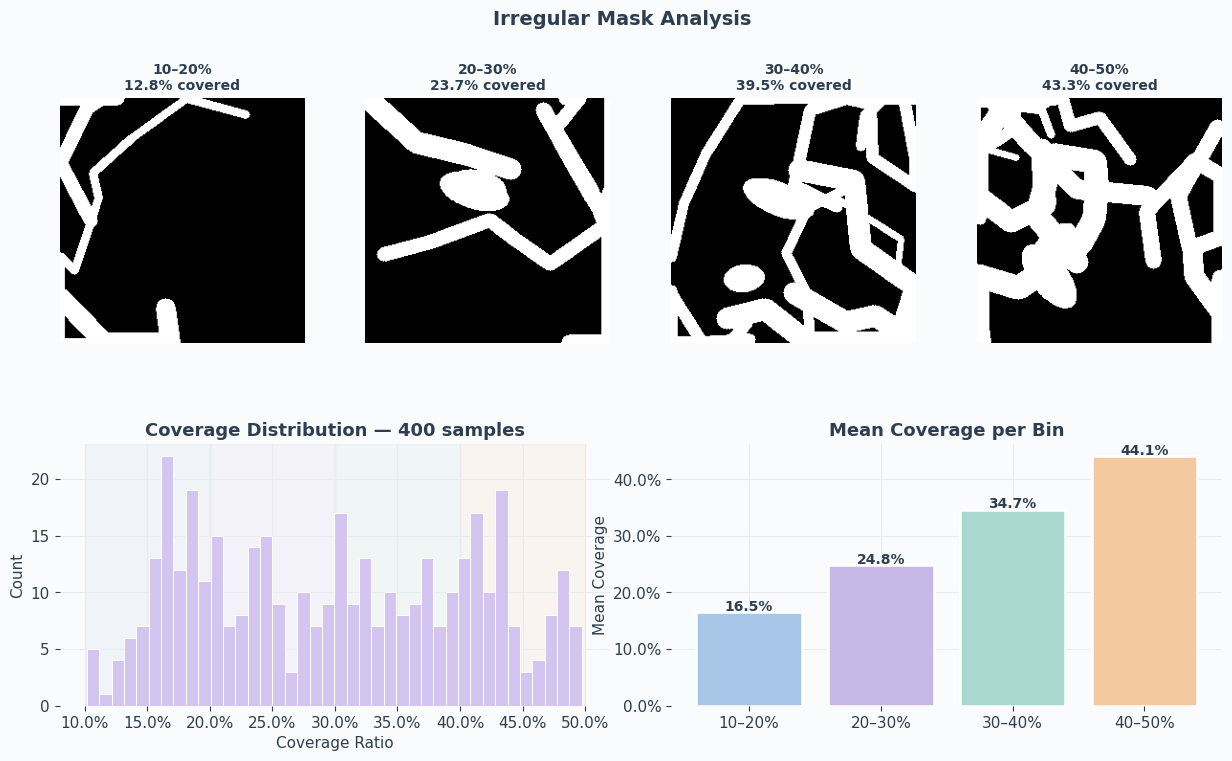

In [9]:
# ── PLOT D: Mask gallery & coverage distribution ──────────────────
fig = plt.figure(figsize=(15, 8))
fig.suptitle('Irregular Mask Analysis', fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.25)

# Row 0: one mask per bin
for col, (lo, hi, lbl) in enumerate(MASK_BINS):
    m  = mask_gen.generate(lo, hi, seed=SEED+col)
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(m, cmap='Greys_r', vmin=0, vmax=255)
    ax.set_title(f'{lbl}\n{m.mean()/255*100:.1f}% covered',
                 fontsize=10, fontweight='bold')
    ax.axis('off')

# Compute coverage of 400 generated masks
ratios = [mask_gen.generate(*MASK_BINS[k%4][:2],
                             seed=SEED+k+1000).mean()/255
          for k in range(400)]

# Row 1 left: histogram
ax_h = fig.add_subplot(gs[1, :2])
ax_h.hist(ratios, bins=40, color=PASTEL['lavender'],
          edgecolor='white', linewidth=0.7, zorder=3)
for idx, (lo, hi, _) in enumerate(MASK_BINS):
    ax_h.axvspan(lo, hi, alpha=0.12, color=PAL[idx])
ax_h.set_xlabel('Coverage Ratio')
ax_h.set_ylabel('Count')
ax_h.set_title('Coverage Distribution — 400 samples')
ax_h.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Row 1 right: mean per bin
ax_b = fig.add_subplot(gs[1, 2:])
means = [np.mean(ratios[i::4]) for i in range(4)]
bars  = ax_b.bar([b[2] for b in MASK_BINS], means,
                 color=[PASTEL['blue'], PASTEL['purple'],
                        PASTEL['teal'],  PASTEL['peach']],
                 edgecolor='white', linewidth=1.8, zorder=3)
for b, v in zip(bars, means):
    ax_b.text(b.get_x()+b.get_width()/2, v+0.003,
              f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax_b.set_ylabel('Mean Coverage')
ax_b.set_title('Mean Coverage per Bin')
ax_b.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.savefig(CACHE_DIR / 'eda_04_masks.png')
plt.show()

---
## 6 · Dataset Class & DataLoader

In [10]:
class InpaintingDataset(Dataset):
    """
    Returns per sample:
        'image'  : (3,H,W) float32 in [-1, 1]  — ground truth
        'masked' : (3,H,W) float32 in [-1, 1]  — image with hole
        'mask'   : (1,H,W) float32 {0,1}       — 1 = missing pixel
        'edge'   : (1,H,W) float32 [0, 1]      — Canny edge map
        'gray'   : (1,H,W) float32 [-1, 1]     — grayscale
    """
    def __init__(self, img_paths, mask_paths,
                 split='train', mask_lo=0.10, mask_hi=0.50):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths
        self.use_gen    = len(mask_paths) == 0
        self.gen        = MaskGenerator(IMG_SIZE)
        self.mask_lo    = mask_lo
        self.mask_hi    = mask_hi

        self.img_tf  = train_transform() if split == 'train' else val_transform()
        self.gray_tf = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.Grayscale(1),
            T.ToTensor(),
            T.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.img_paths)

    def _mask(self, idx):
        if self.use_gen:
            m = self.gen.generate(self.mask_lo, self.mask_hi)
        else:
            mp = self.mask_paths[idx % len(self.mask_paths)]
            m  = np.array(Image.open(mp).convert('L').resize(
                    (IMG_SIZE, IMG_SIZE), Image.NEAREST))
        return (m > 127).astype(np.float32)

    def __getitem__(self, idx):
        pil    = Image.open(self.img_paths[idx]).convert('RGB')
        img    = self.img_tf(pil)                              # (3,H,W)
        gray   = self.gray_tf(pil)                             # (1,H,W)
        mask   = torch.from_numpy(self._mask(idx)).unsqueeze(0)# (1,H,W)
        masked = img * (1 - mask)
        edge   = torch.from_numpy(
                     canny_edges(to_np(img))).unsqueeze(0)     # (1,H,W)
        return {'image': img, 'masked': masked,
                'mask': mask, 'edge': edge, 'gray': gray}


pin = torch.cuda.is_available()
loaders = {
    split: DataLoader(
        InpaintingDataset(splits[split], mask_paths,
                          split=split),
        batch_size  = BATCH_SIZE,
        shuffle     = (split == 'train'),
        num_workers = min(N_WORKERS, os.cpu_count() or 1),
        pin_memory  = pin,
        drop_last   = (split == 'train'),
    )
    for split in ('train', 'val', 'test')
}

print('DataLoader summary:')
for k, dl in loaders.items():
    print(f'  {k:<6}: {len(dl.dataset):>7,} images  |  {len(dl):>5,} batches')

DataLoader summary:
  train : 162,079 images  |  10,129 batches
  val   :  20,259 images  |  1,267 batches
  test  :  20,261 images  |  1,267 batches


---
## 7 · Batch Verification

  key      shape                       min    max    mean
  ──────────────────────────────────────────────────────
  image    (16, 3, 256, 256)        -1.000  1.000  -0.127
  masked   (16, 3, 256, 256)        -1.000  1.000  -0.024
  mask     (16, 1, 256, 256)         0.000  1.000   0.820
  edge     (16, 1, 256, 256)         0.000  1.000   0.066
  gray     (16, 1, 256, 256)        -1.000  1.000  -0.116


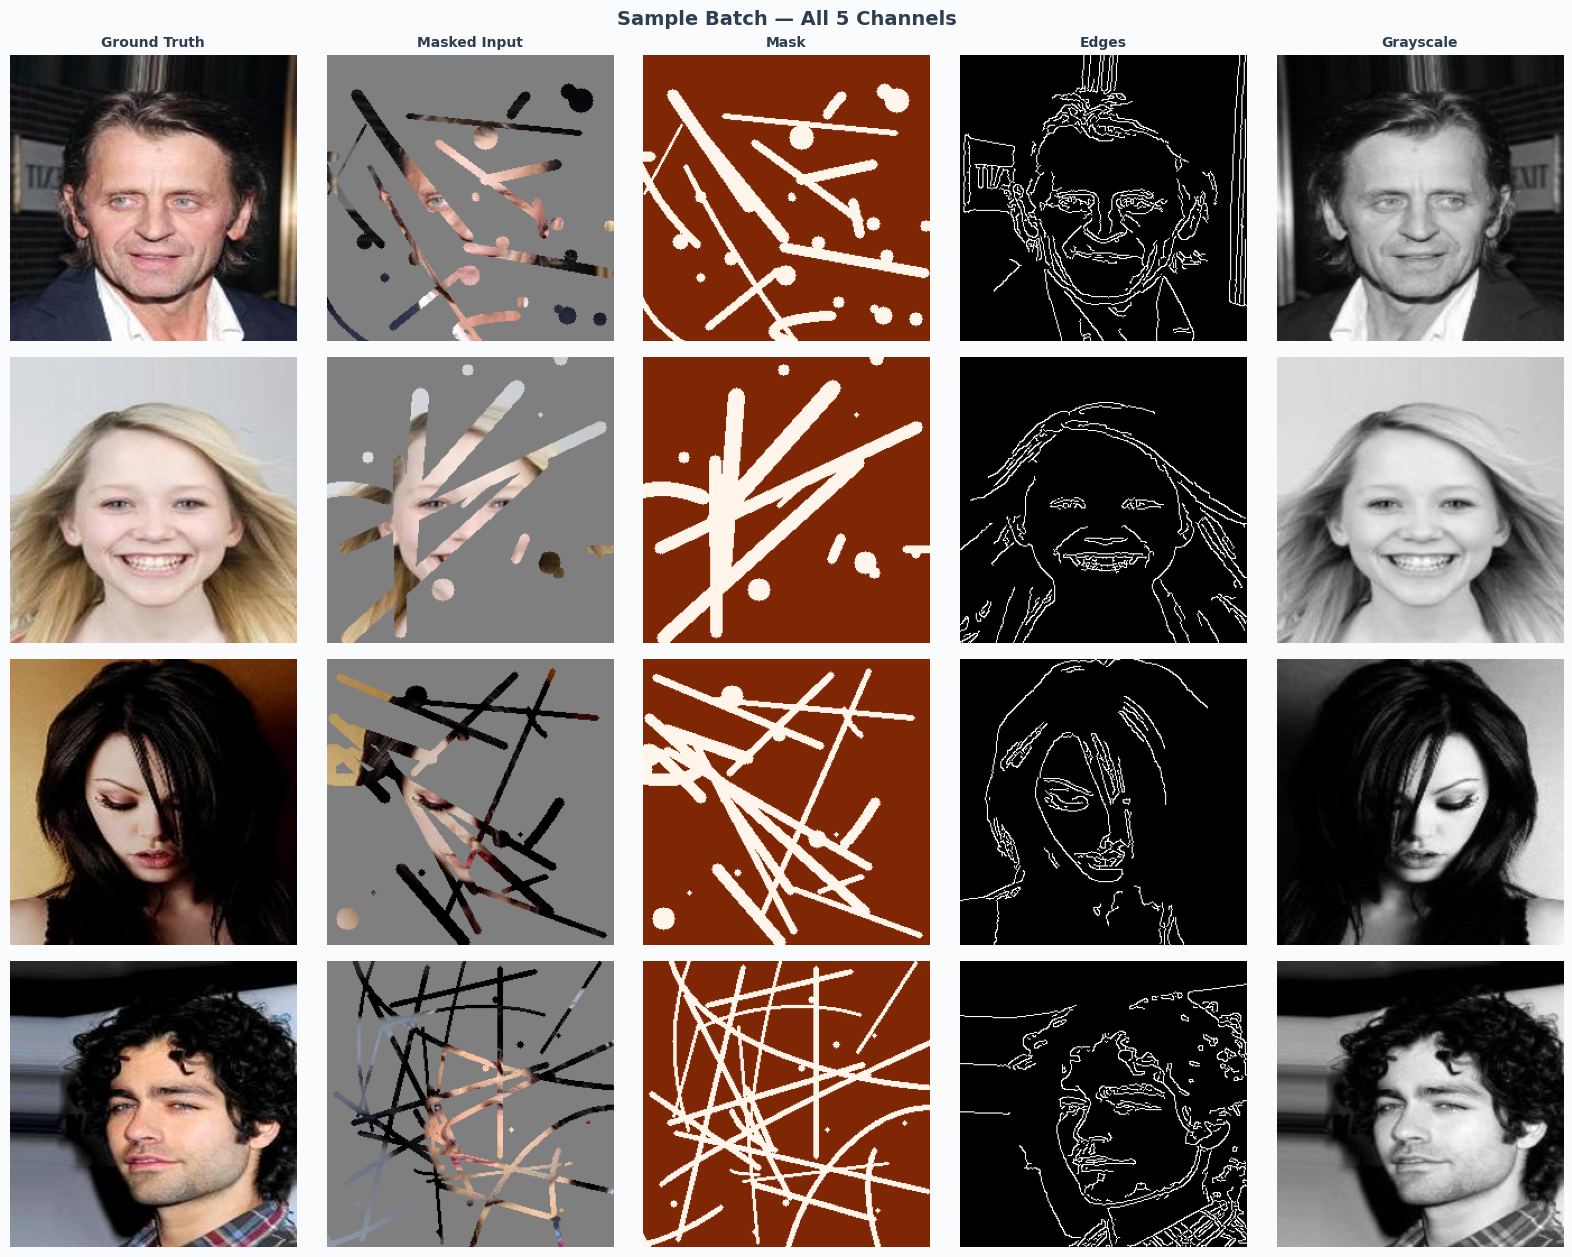


✅  Batch verification passed.


In [11]:
batch = next(iter(loaders['train']))

print(f'  {"key":<8} {"shape":<24} {"min":>6} {"max":>6} {"mean":>7}')
print('  ' + '─' * 54)
for k, v in batch.items():
    print(f'  {k:<8} {str(tuple(v.shape)):<24} '
          f'{v.min().item():>6.3f} {v.max().item():>6.3f} '
          f'{v.mean().item():>7.3f}')

# ── PLOT E: Sample batch ──────────────────────────────────────────
n     = min(4, BATCH_SIZE)
cols  = ['Ground Truth', 'Masked Input', 'Mask', 'Edges', 'Grayscale']
fig, axes = plt.subplots(n, 5, figsize=(16, n*3.2))
fig.suptitle('Sample Batch — All 5 Channels',
             fontsize=14, fontweight='bold')

for j, title in enumerate(cols):
    axes[0][j].set_title(title, fontsize=10, fontweight='bold')

for row in range(n):
    for col, (img, cmap) in enumerate([
            (to_np(batch['image'][row]),  None),
            (to_np(batch['masked'][row]), None),
            (batch['mask'][row,0].numpy(),   'Oranges'),
            (batch['edge'][row,0].numpy(),   'Greys_r'),
            (batch['gray'][row,0].numpy(),   'gray')]):
        axes[row][col].imshow(img, cmap=cmap)
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig(CACHE_DIR / 'eda_05_batch.png')
plt.show()
print('\n✅  Batch verification passed.')

---
## 8 · Save Artefacts for Notebook 2

In [12]:
artefacts = {
    'split_train'  : [str(p) for p in splits['train']],
    'split_val'    : [str(p) for p in splits['val']],
    'split_test'   : [str(p) for p in splits['test']],
    'mask_paths'   : [str(p) for p in mask_paths],
    'img_size'     : IMG_SIZE,
    'batch_size'   : BATCH_SIZE,
    'num_workers'  : N_WORKERS,
    'gan_mean'     : GAN_MEAN,
    'gan_std'      : GAN_STD,
    'seed'         : SEED,
}
with open(CACHE_DIR / 'nb1_artefacts.json', 'w') as f:
    json.dump(artefacts, f, indent=2)

print('✅  Saved → data/cache/nb1_artefacts.json')
print()
print('═' * 46)
print('  NOTEBOOK 1 — COMPLETE')
print('═' * 46)
print(f'  Train   : {len(splits["train"]):>8,}')
print(f'  Val     : {len(splits["val"]):>8,}')
print(f'  Test    : {len(splits["test"]):>8,}')
print(f'  Masks   : {len(mask_paths):>8,}')
print(f'  Batches : {len(loaders["train"]):>8,}')
print('═' * 46)
print('  → Open Notebook 2 to train the model.')

✅  Saved → data/cache/nb1_artefacts.json

══════════════════════════════════════════════
  NOTEBOOK 1 — COMPLETE
══════════════════════════════════════════════
  Train   :  162,079
  Val     :   20,259
  Test    :   20,261
  Masks   :   32,000
  Batches :   10,129
══════════════════════════════════════════════
  → Open Notebook 2 to train the model.
